# Analytic disk

We create a Magritte model from an analytic description of a Keplerian disk (see e.g. [Homan et al. 2018](https://doi.org/10.1051/0004-6361/201732246); [Booth et al. 2019](https://doi.org/10.1051/0004-6361/201834388)).

## Setup

Import the required functionalty.

In [34]:
import magritte.setup    as setup                   # Model setup
import magritte.core     as magritte                # Core functionality
import magritte.plot  as plot                 # Plotting
import magritte.mesher   as mesher                  # Mesher
import numpy             as np                      # Data structures
import warnings                                     # Hide warnings
warnings.filterwarnings('ignore')                   # especially for yt
import yt                                           # 3D plotting
import os

from tqdm                import tqdm                # Progress bars
from astropy             import units, constants    # Unit conversions
from scipy.spatial       import Delaunay, cKDTree   # Finding neighbors
from yt.funcs            import mylog               # To avoid yt output 

mylog.setLevel(40)                                  # as error messages

In [35]:
magritte.__version__

'0.9.10'

Define a working directory (you will have to change this; it must be an **absolute path**).

In [36]:
wdir = "/home/yasho379/magritte_rebuilt/tgs"

Create the working directory.

Define file names.

In [37]:
model_file = os.path.join(wdir, 'model_analytic_sphere_hcn.hdf5')   # Resulting Magritte model
lamda_file = os.path.join(wdir, 'hcn@hfs.modified.dat.txt'               )   # Line data file
bmesh_name = os.path.join(wdir, 'analytic_sphere'           )   # background mesh name (no extension!)

We use a data file that can be downloaded with the following links.

In [38]:
# lamda_link = "https://home.strw.leidenuniv.nl/~moldata/datafiles/p-nh3@loreau.dat"

Dowload the snapshot and the linedata (``%%capture`` is just used to suppress the output).

In [39]:
%%capture
#!wget $lamda_link --output-document $lamda_file

## Model parameters

The functions below describe the disk structure, based on the Magritte application presented in [De Ceuster et al. (2019)](https://doi.org/10.1093/mnras/stz3557).

Function 1 max: 212.83632327098968
Function 2 max: 259.96448572604896
Function 3 max: 100500000000.0


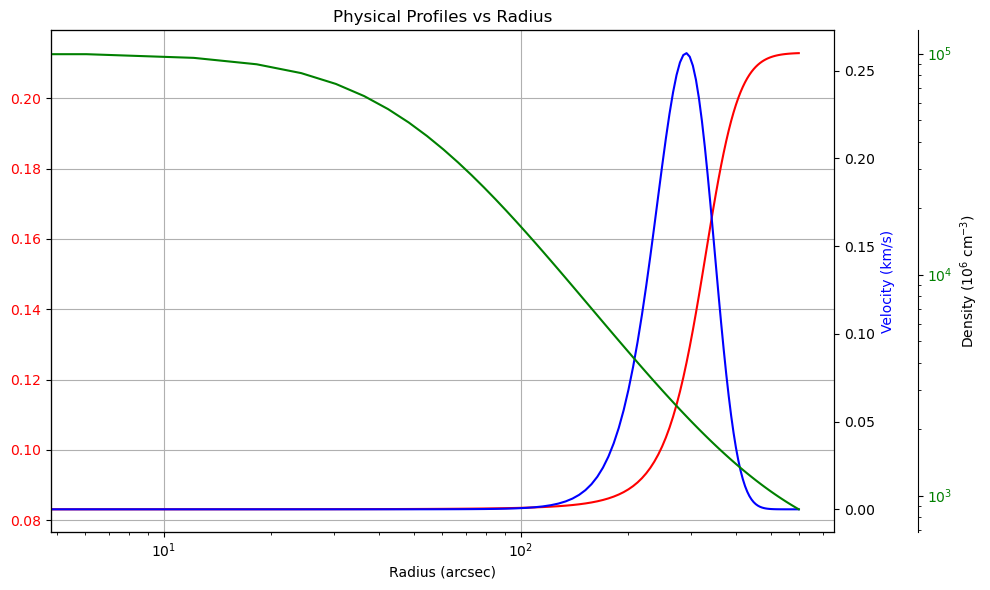

In [40]:
G      =           constants.G.si.value
kb     =           constants.k_B.si.value
m_H2   = 2.01588 * constants.u.si.value

#XCO    =  6.0e-4   # [.]
XHCN_1    =  2.6e-9   # [.]
XHCN_2 =  6.1e-9   # [.]
T_cloud =  10 # [K]

r_out  =   (1000 * 4.84814e-6 * 140 *constants.pc.si.value)
r_in   =    1.0 * constants.au.si.value
r_0 = 47 * 4.84814e-6 * 140 *constants.pc.si.value #length scale in si units (47 arcsec at 140 pc)

def temperature(rr):
    return T_cloud # constant temperature cloud assumed for spectra generation
        
def radius(rr):
    """
    Returns the radius from the origin to the point rr in units of the model, usually AU
    """
    return (rr[0]**2. + rr[1]**2. + rr[2]**2.)**0.5


def density(rr):
    rho_0 = rho_cloud  # central density in si units
    
    alpha =2.2   # power-law index
    r_max = r_out  # outer cutoff radius in AU

    # Compute radial distance
    Radius = radius(rr)
    # Calculate density profile
    GasDensity = rho_0 / (1.0 + (Radius / r_0)**alpha) + 500 * 1.0E6 * m_H2 # [kg/m^3]

    # Apply cutoff beyond r_out
    if hasattr(Radius, "__len__"):
        GasDensity[Radius > r_max] = 0.0
    else:
        if Radius > r_max:
            GasDensity = 0.0

    return GasDensity

def abn_nH2(rr):
    """
    H2 number density function.
    """
    return density(rr) / (2.01588 * m_H2)

import numpy as np
import astropy.units as u
from astropy.constants import c

# Parameters with explicit units
rho_cloud = 1.0E5 * 1.0E6 * m_H2   # [kg/m^3]

#arsecond values assuming distance of 140 pc
rj = (320 * 4.84814e-6 * 140 *constants.pc.si.value)
d_rj = (78 * 4.84814e-6 * 140 *constants.pc.si.value)
r1 = (33 * 4.84814e-6 * 140 *constants.pc.si.value)
rV = (290 * 4.84814e-6 * 140 *constants.pc.si.value)
d_rV = (55 * 4.84814e-6 * 140 *constants.pc.si.value)

#values of velocity parameters 
sigma0 = (0.046 * 1000)
sigma_ext = (0.25 * 1000)
Vc = (-0.26 * 1000)

def velocity_r(rr):
    """
    Radial velocity profile V(r) [Eq. 5]
    r : astropy quantity with angular units (arcsec)
    Returns V in m/s
    """
    x, y, z = rr[0], rr[1], rr[2]
    r = np.sqrt(x**2 + y**2 + z**2)
    v_radial = Vc * np.exp(-((r - rV)**2) / (2 * d_rV**2))
    v_radial = 1.5e-18*r
    if hasattr(r, "__len__"):
        v = np.zeros((3,) + r.shape)
        v[0] = v_radial * (x / r)
        v[1] = v_radial * (y / r)
        v[2] = v_radial * (z / r)
    else:
        v = np.array([v_radial * (x / r), v_radial * (y / r), v_radial * (z / r)])
    return v/3e8 # Convert to fraction of speed of light

def turbulence(rr):
    """
    Nonthermal velocity dispersion σ_nth(r) [Eq. 6]
    r : astropy quantity with angular units (arcsec)
    Returns σ_nth in m/s
    """
    r = radius(rr)
    term = (np.pi/2) + np.tanh(((r - rj)/d_rj))
    val = (sigma0 + ((sigma_ext - sigma0)/np.pi) * term)/2.3458
    return (val/(3e8))**2

def abn_nHCN(rr):
    """
    Abundance profile X(r) [Eq. 7]
    r : astropy quantity with angular units (arcsec)
    eta : scaling factor (unitless)
    Returns abundance (unitless)
    """
    r = radius(rr)
    return np.where(r < r1, XHCN_1*abn_nH2(rr), XHCN_2*abn_nH2(rr)) 

def plot_functions(positions):
    alpha =2.2
    def function1(r):
        term = (np.pi/2) + np.tanh(((r - rj)/d_rj))
        val = (sigma0 + ((sigma_ext - sigma0)/np.pi) * term)
        return val
    def function2(r):
        v_radial = Vc * np.exp(-((r - rV)**2) / (2 * d_rV**2))
        return -v_radial
    def function3(r):
        val = rho_cloud / ((1.0 + (r / r_0)**alpha)*m_H2) + 500 * 1.0E6  # in cm^-3
        return val
    import matplotlib.pyplot as plt
    # Calculate function values
    f1 = function1(positions[0])
    f2 = function2(positions[0])
    f3 = function3(positions[0])

    print("Function 1 max:", np.max(f1))
    print("Function 2 max:", np.max(f2))
    print("Function 3 max:", np.max(f3))
    # Plot the functions with velocities in km/s on a linear scale on the right y-axis and densities on a log scale on the left y axis
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(positions[0]/(4.84814e-6 * 140 *constants.pc.si.value), f1/1000, label='Turbulence (km/s)', color='red')
    ax1.set_xscale('log')
    ax1.set_xlabel('Radius (arcsec)')
    ax1.set_title('Physical Profiles vs Radius')
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid()
    ax2 = ax1.twinx()
    ax2.plot(positions[0]/(4.84814e-6 * 140 *constants.pc.si.value), f2/1000, label='Radial Velocity (km/s)', color='blue')
    ax2.set_ylabel('Velocity (km/s)', color='blue')
    ax2.tick_params(axis='y', labelcolor='black')
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))  # Offset the third y-axis
    ax3.plot(positions[0]/(4.84814e-6 * 140 *constants.pc.si.value), f3/1e6, label='Density (cm$^{-3}$)', color='green')
    ax3.set_ylabel('Density (10$^6$ cm$^{-3}$)', color='black')
    ax3.set_yscale('log')
    ax3.tick_params(axis='y', labelcolor='green')
    fig.tight_layout()
    plt.show()
    


xs = np.linspace(0, 600 * 4.84814e-6 * 140 *constants.pc.si.value, 100)
ys = np.zeros_like(xs)
zs = np.zeros_like(xs)
positions = np.array([xs, ys, zs])
plot_functions(positions)



## Create background mesh

Define the desired background mesh, a ($75 \times 75 \times 75$) cube.

In [41]:
resolution = 75

xs = np.linspace(-r_out*1.1, +r_out*1.1, resolution, endpoint=True)
ys = np.linspace(-r_out*1.1, +r_out*1.1, resolution, endpoint=True)
zs = np.linspace(-r_out*1.1, +r_out*1.1, resolution, endpoint=True)

(Xs, Ys, Zs) = np.meshgrid(xs, ys, zs)

# Extract positions of points in background mesh
position = np.array((Xs.ravel(), Ys.ravel(), Zs.ravel())).T

# Evaluate the density on the cube
rhos      = density([Xs, Ys, Zs])
rhos_min  = np.min(rhos[rhos!=0.0])
rhos     += rhos_min

Now we remesh this model using the new remesher

In [42]:
positions_reduced, nb_boundary = mesher.remesh_point_cloud(position, rhos.ravel(), max_depth=10, threshold= 2e-1, hullorder=4)

new interior points:  28668
number boundary points:  1538


We add a spherical inner boundary at 0.01*r_out

In [43]:
healpy_order = 5 #using healpy to determine where to place the 12*healpy_order**2 boundary points on the sphere
origin = np.array([0.0,0.0,0.0]).T #the origin of the inner boundary sphere
positions_reduced, nb_boundary = mesher.point_cloud_add_spherical_inner_boundary(positions_reduced, nb_boundary, 0.01*r_out, healpy_order=healpy_order, origin=origin)
print("number of points in reduced grid: ", len(positions_reduced))
print("number of boundary points: ", nb_boundary)

number of points in reduced grid:  30505
number of boundary points:  1838


We add a spherical outer boundary at r_out

In [44]:
healpy_order = 15 #using healpy to determine where to place the 12*healpy_order**2 boundary points on the sphere
origin = np.array([0.0,0.0,0.0]).T #the origin of the inner boundary sphere
positions_reduced, nb_boundary = mesher.point_cloud_add_spherical_outer_boundary(positions_reduced, nb_boundary, r_out, healpy_order=healpy_order, origin=origin)
print("number of points in reduced grid: ", len(positions_reduced))

number of points in reduced grid:  16965


In [45]:
npoints = len(positions_reduced)

# Extract Delaunay vertices (= Voronoi neighbors)
delaunay = Delaunay(positions_reduced)
(indptr, indices) = delaunay.vertex_neighbor_vertices
neighbors = [indices[indptr[k]:indptr[k+1]] for k in range(npoints)]
nbs       = [n for sublist in neighbors for n in sublist]
n_nbs     = [len(sublist) for sublist in neighbors]

# Convenience arrays
zeros = np.zeros(npoints)
ones  = np.ones (npoints)

Convert model functions to arrays based the model mesh.

In [46]:
position = positions_reduced
velocity = np.array([velocity_r (rr) for rr in positions_reduced])
nH2      = np.array([abn_nH2    (rr) for rr in positions_reduced])
nHCN      = np.array([abn_nHCN   (rr) for rr in positions_reduced])
tmp      = np.array([temperature(rr) for rr in positions_reduced])
trb      = np.array([turbulence (rr) for rr in positions_reduced])



## Create model

Now all data is read, we can use it to construct a Magritte model.

<div class="alert alert-warning">

Warning

Since we do not aim to do self-consistent non-LTE simulations in these examples, we only consider the first radiative transition of CO (J=1-0). To consider all transitions, use `setup.set_linedata_from_LAMDA_file` as in the commented line below it.
We also only consider 2 rays here (up and down the direction we want to image). To consider all directions, comment out the indecated lines and use `setup.set_uniform_rays` as in the commented line below.
    
</div>

In [47]:
model = magritte.Model ()                              # Create model object

model.parameters.set_model_name         (model_file)   # Magritte model file
model.parameters.set_dimension          (3)            # This is a 3D model
model.parameters.set_npoints            (npoints)      # Number of points
model.parameters.set_nrays              (2)            # Number of rays  
model.parameters.set_nspecs             (3)            # Number of species (min. 5)
model.parameters.set_nlspecs            (1)            # Number of line species
model.parameters.set_nquads             (51)           # Number of quadrature points

model.geometry.points.position.set(position)
model.geometry.points.velocity.set(velocity)

model.geometry.points.  neighbors.set(  nbs)
model.geometry.points.n_neighbors.set(n_nbs)

model.chemistry.species.abundance = np.array((nHCN, nH2, zeros)).T
model.chemistry.species.symbol    = ['HCN', 'H2', 'e-']

model.thermodynamics.temperature.gas  .set(tmp)
model.thermodynamics.turbulence.vturb2.set(trb)

model.parameters.set_nboundary(nb_boundary)
model.geometry.boundary.boundary2point.set(np.arange(nb_boundary))

direction = np.array([[+1,0,0], [-1,0,0]])            # Comment out to use all directions
model.geometry.rays.direction.set(direction)          # Comment out to use all directions
model.geometry.rays.weight   .set(0.5 * np.ones(2))   # Comment out to use all directions

# setup.set_uniform_rays            (model)   # Uncomment to use all directions

setup.set_boundary_condition_CMB  (model)
#setup.set_boundary_condition_zero  (model)
#setup.set_linedata_from_LAMDA_file(model, lamda_file, {'considered transitions': [0,1]})  # Consider only CO lines
setup.set_linedata_from_LAMDA_file(model, lamda_file)   # Consider all transitions
setup.set_quadrature              (model)

model.write()

[1, 2, 1, 3.0351e-11, 2.4556e-11, 2.2104e-11, 2.199e-11, 2.2275e-11, 2.2357e-11, 2.2198e-11, 2.1662e-11, 2.1068e-11, 1.9999e-11, 1.9138e-11, 1.845e-11]
[2, 3, 1, 3.0351e-11, 2.4556e-11, 2.2104e-11, 2.199e-11, 2.2275e-11, 2.2357e-11, 2.2198e-11, 2.1662e-11, 2.1068e-11, 1.9999e-11, 1.9138e-11, 1.845e-11]
[3, 3, 2, 1.1755e-11, 1.451e-11, 2.0467e-11, 2.5878e-11, 3.4489e-11, 4.0699e-11, 4.7042e-11, 5.321e-11, 5.6657e-11, 6.0231e-11, 6.2102e-11, 6.3373e-11]
[4, 4, 1, 3.0351e-11, 2.4556e-11, 2.2104e-11, 2.199e-11, 2.2275e-11, 2.2357e-11, 2.2198e-11, 2.1662e-11, 2.1068e-11, 1.9999e-11, 1.9138e-11, 1.845e-11]
[5, 4, 2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[6, 4, 3, 2.6121e-11, 3.2245e-11, 4.5481e-11, 5.7507e-11, 7.6642e-11, 9.0441e-11, 1.0454e-10, 1.1824e-10, 1.259e-10, 1.3385e-10, 1.38e-10, 1.4083e-10]
[7, 5, 1, 1.3061e-11, 1.6123e-11, 2.2741e-11, 2.8753e-11, 3.8321e-11, 4.5221e-11, 5.2269e-11, 5.9122e-11, 6.2952e-11, 6.6923e-11, 6.9002e-11, 7.0415e-11]
[8, 5, 2, 1.5699e

## Plot model

Load the data in a `yt` unstructured mesh.

In [48]:
ds = yt.load_unstructured_mesh(
    connectivity = delaunay.simplices.astype(np.int64),
    coordinates  = delaunay.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'n'): nHCN[delaunay.simplices].astype(np.float64)}
)

Plot a slice through the mesh orthogonal to the z-axis and x-axis.


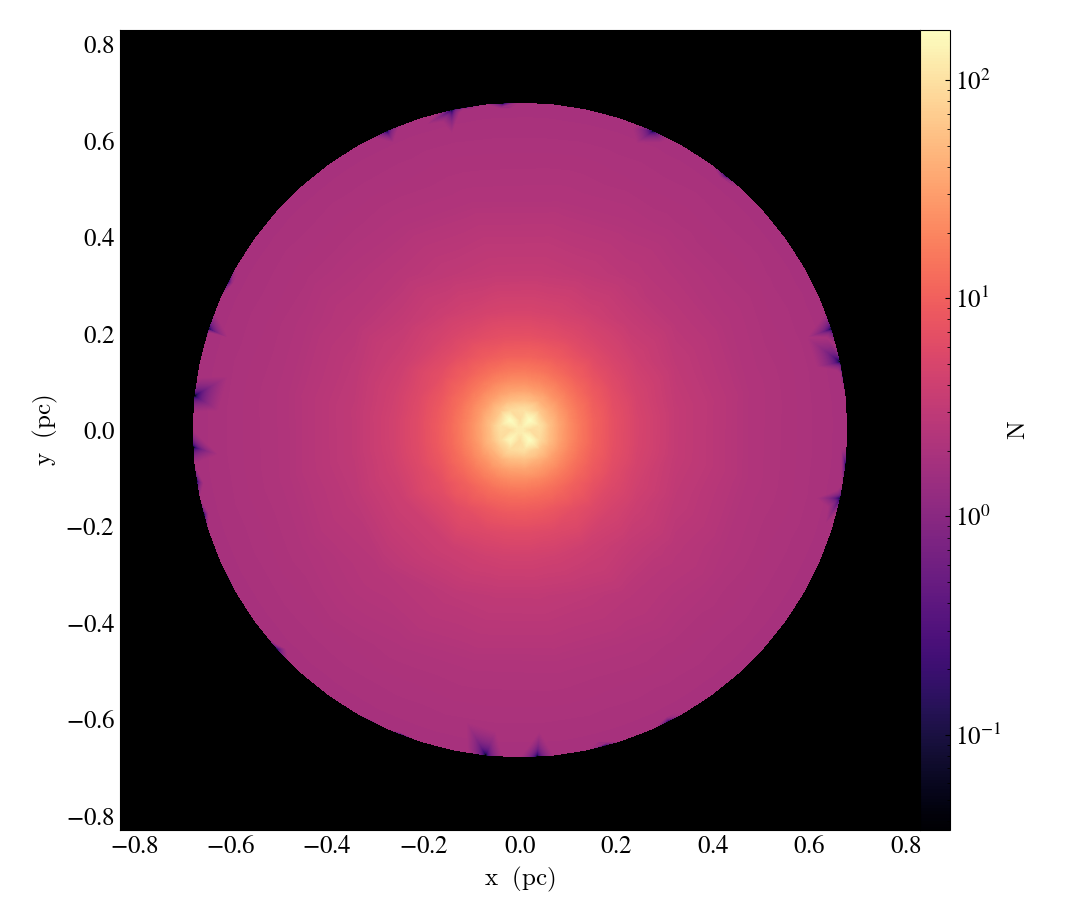

In [49]:
sl = yt.SlicePlot (ds, 'z', ('connect1', 'n'))
sl.set_cmap       (('connect1', 'n'), 'magma')
sl.zoom           (0.9)


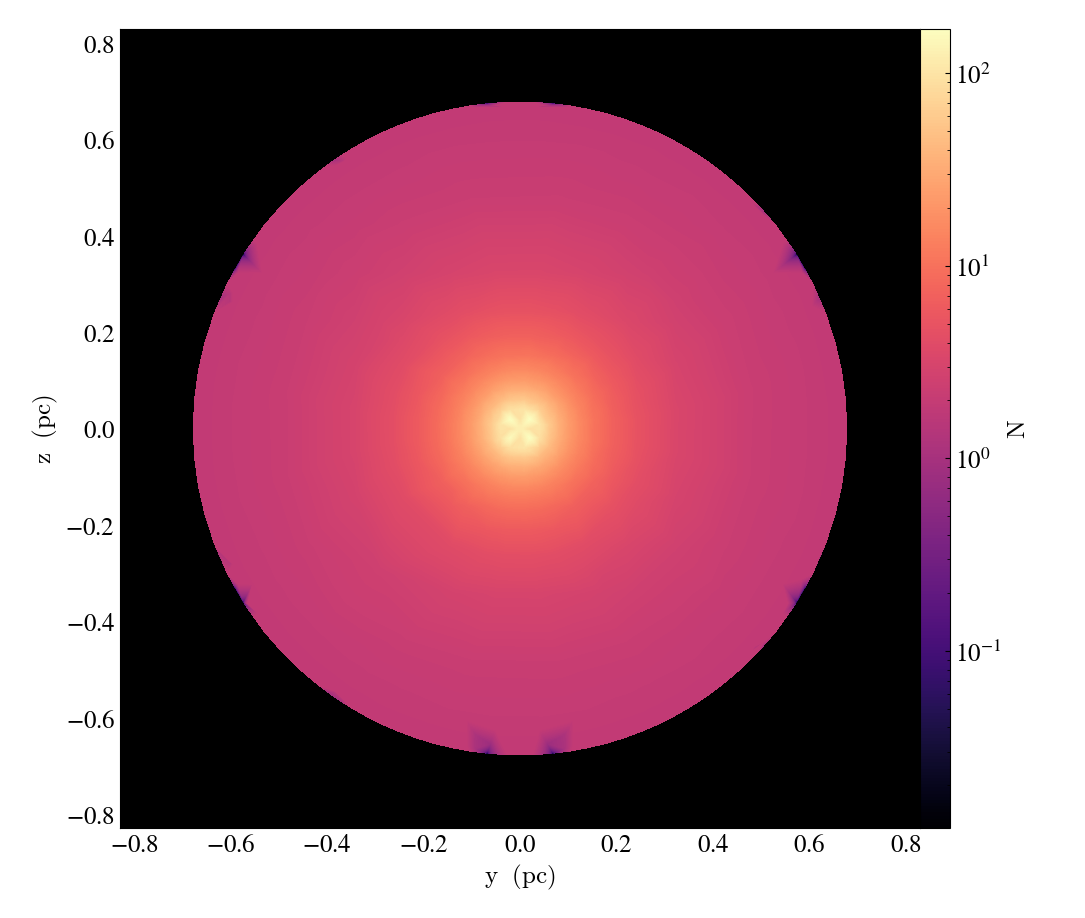

In [50]:
sl = yt.SlicePlot (ds, 'x', ('connect1', 'n'))
sl.set_cmap       (('connect1', 'n'), 'magma')
sl.zoom           (0.9)

Show meshes on the plots.


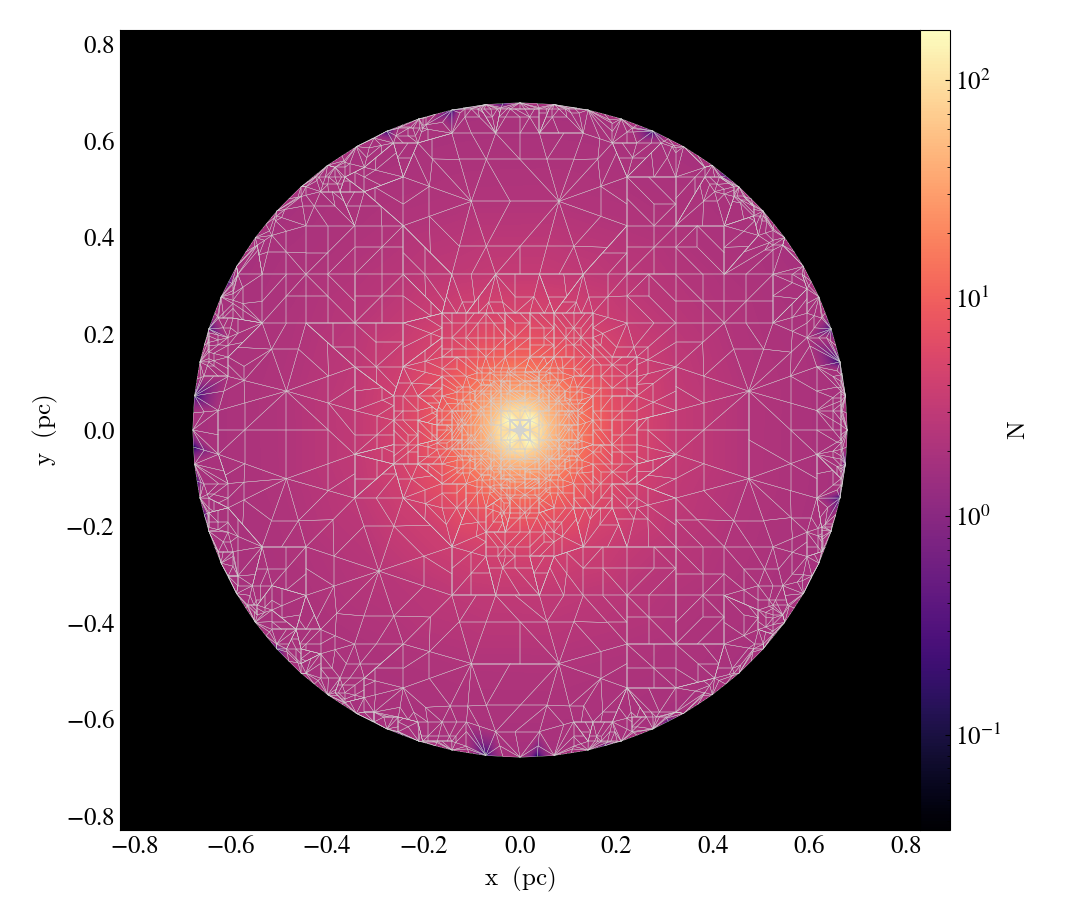

In [51]:
sl = yt.SlicePlot      (ds, 'z', ('connect1', 'n'))
sl.set_cmap            (('connect1', 'n'), 'magma')
sl.zoom                (0.9)
sl.annotate_mesh_lines (plot_args={'color':'lightgrey', 'linewidths':[.25]})


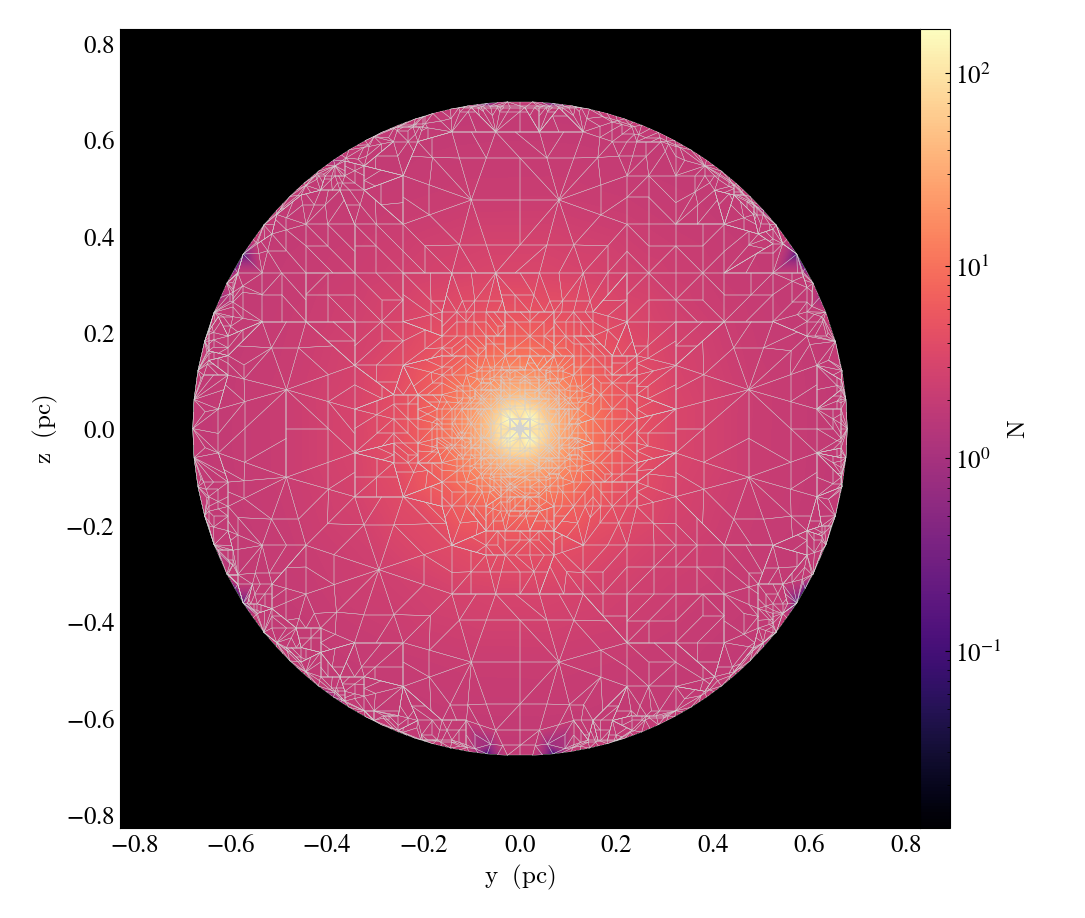

In [52]:
sl = yt.SlicePlot      (ds, 'x', ('connect1', 'n'))
sl.set_cmap            (('connect1', 'n'), 'magma')
sl.zoom                (0.9)
sl.annotate_mesh_lines (plot_args={'color':'lightgrey', 'linewidths':[.25]})

In [53]:
model_file = os.path.join(wdir, 'model_analytic_sphere_hcn.hdf5')   # Resulting Magritte model

In [54]:
model = magritte.Model(model_file)

                                           
-------------------------------------------
  Reading Model...                         
-------------------------------------------
 model file = /home/yasho379/magritte_rebuilt/tgs/model_analytic_sphere_hcn.hdf5
-------------------------------------------
Reading parameters...
Reading points...
Reading rays...
Reading boundary...
Reading chemistry...
Reading species...
Reading thermodynamics...
Reading temperature...
Reading turbulence...
Reading lines...
Reading lineProducingSpecies...
Reading linedata...
read num 0
read sym HCN
nlev = 25
nrad = 45
Reading collisionPartner...
Reading quadrature...
Reading radiation...
Reading frequencies...
Not using scattering!
                                           
-------------------------------------------
  Model read, parameters:                  
-------------------------------------------
  npoints    = 16965
  nrays      = 2
  nboundary  = 3000
  nfreqs     = 2295
  nspecs     = 3
  nlspecs   

In [55]:
model.compute_spectral_discretisation ()
model.compute_inverse_line_widths     ()
model.compute_LTE_level_populations   ()

Computing spectral discretisation...
Computing inverse line widths...
Computing LTE level populations...


0

In [56]:
fcen = model.lines.lineProducingSpecies[0].linedata.frequency
print(fcen)

[88630415610.04251, 88631847508.75966, 88633935713.12585, 177258474071.90472, 177259629082.3077, 177259905970.6219, 177260016773.91437, 177261717286.67392, 177263149185.39105, 265884953766.72467, 265887548590.36557, 265886496468.7343, 265886562453.0543, 265889249103.1251, 265890791805.13474, 354506297627.0088, 354505108889.95447, 354507906313.3384, 354507951941.75055, 354507795540.0253, 354509404226.3549, 443113552890.62555, 443115297592.7933, 443115207205.3673, 443115241771.4378, 443115141191.06805, 443116795505.8098, 531715719237.2262, 531717463219.89233, 531717408118.03845, 531717436238.5709, 531717362639.5226, 531719051520.33484, 620300805927.8267, 620302561932.1698, 620302522929.1714, 620302546732.6924, 620302488333.1213, 620304205334.4661, 708874808871.5454, 708876579955.4495, 708876549676.4111, 708876570571.9456, 708876521555.8784, 708878262360.7441]


In [57]:


fcen = model.lines.lineProducingSpecies[0].linedata.frequency[0]
vpix = 1e+3   # velocity pixel size [m/s] 
dd   = vpix * (model.parameters.nfreqs()-1)/2 / magritte.CC
fmax = fcen + fcen*dd
fmin = 2*fcen - fmax  # same as fmin = fcen - fcen*dd


fcen=model.lines.lineProducingSpecies[0].linedata.frequency[1]
fmin=fcen- 3000000.00
fmax=fcen+ 3000000.00
# Ray orthogonal to image plane
ray_nr = 0

model.compute_spectral_discretisation (fmin, fmax,500)#bins the frequency spectrum [fmin, fmax] into model.parameters.nfreqs bins.
# model.compute_spectral_discretisation (fmin, fmax, 31)#bins using the specified amount of frequency bins (31). Can be any integer >=1

model.compute_image_new               (ray_nr, 16, 16)#using a resolution of 512x512 for the image. 
#Instead of definining a ray index [0, nrays-1], you can also define a ray direction for the imager 
#model.compute_image_new              (rx, ry, rz, 512, 512)#in which (rx, ry, rz) is the (normalized) ray direction
#tools.save_fits(model)

Computing spectral discretisation...
Computing image new...
length: 67


0

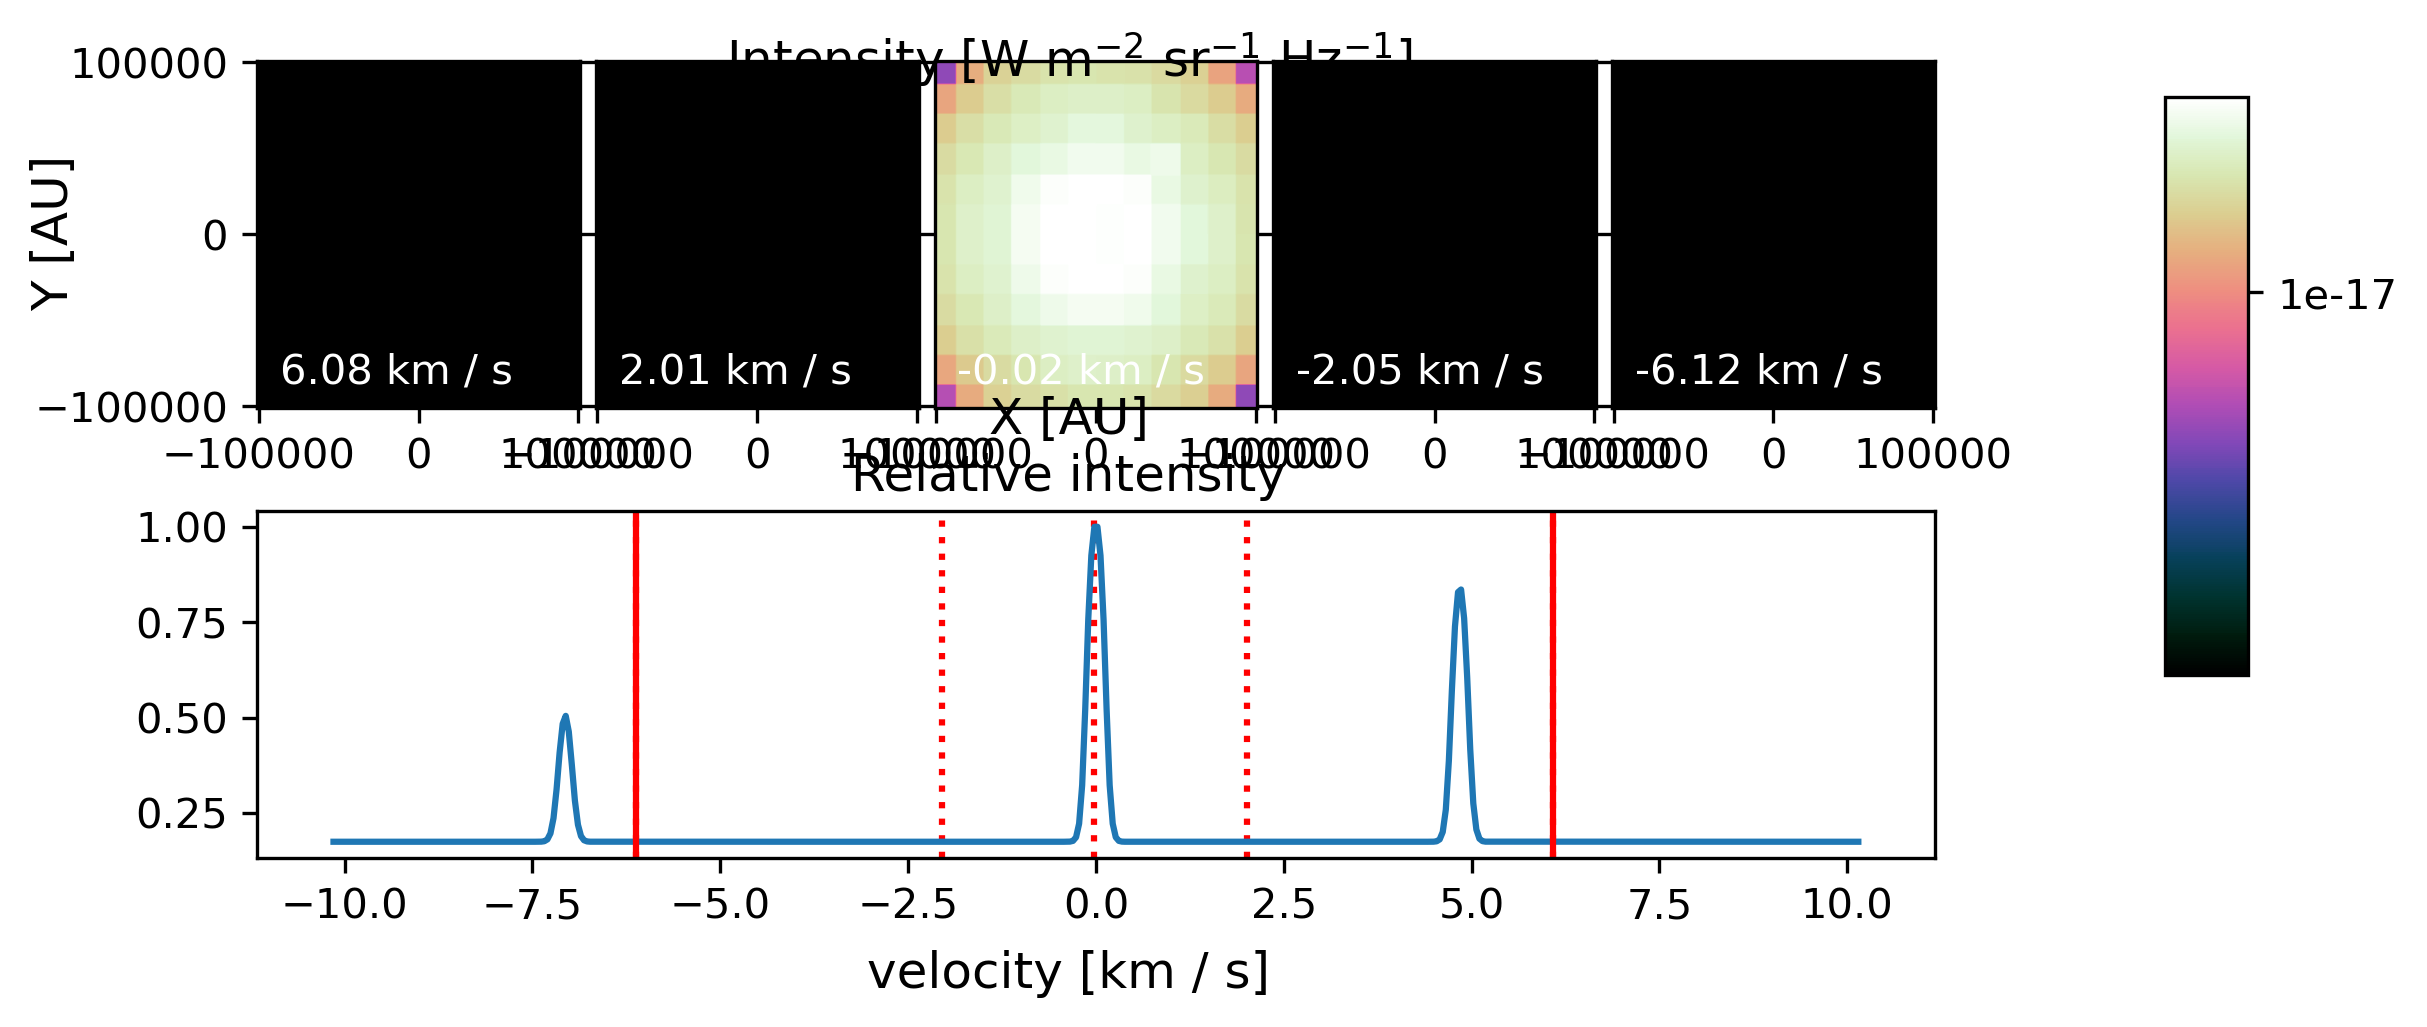

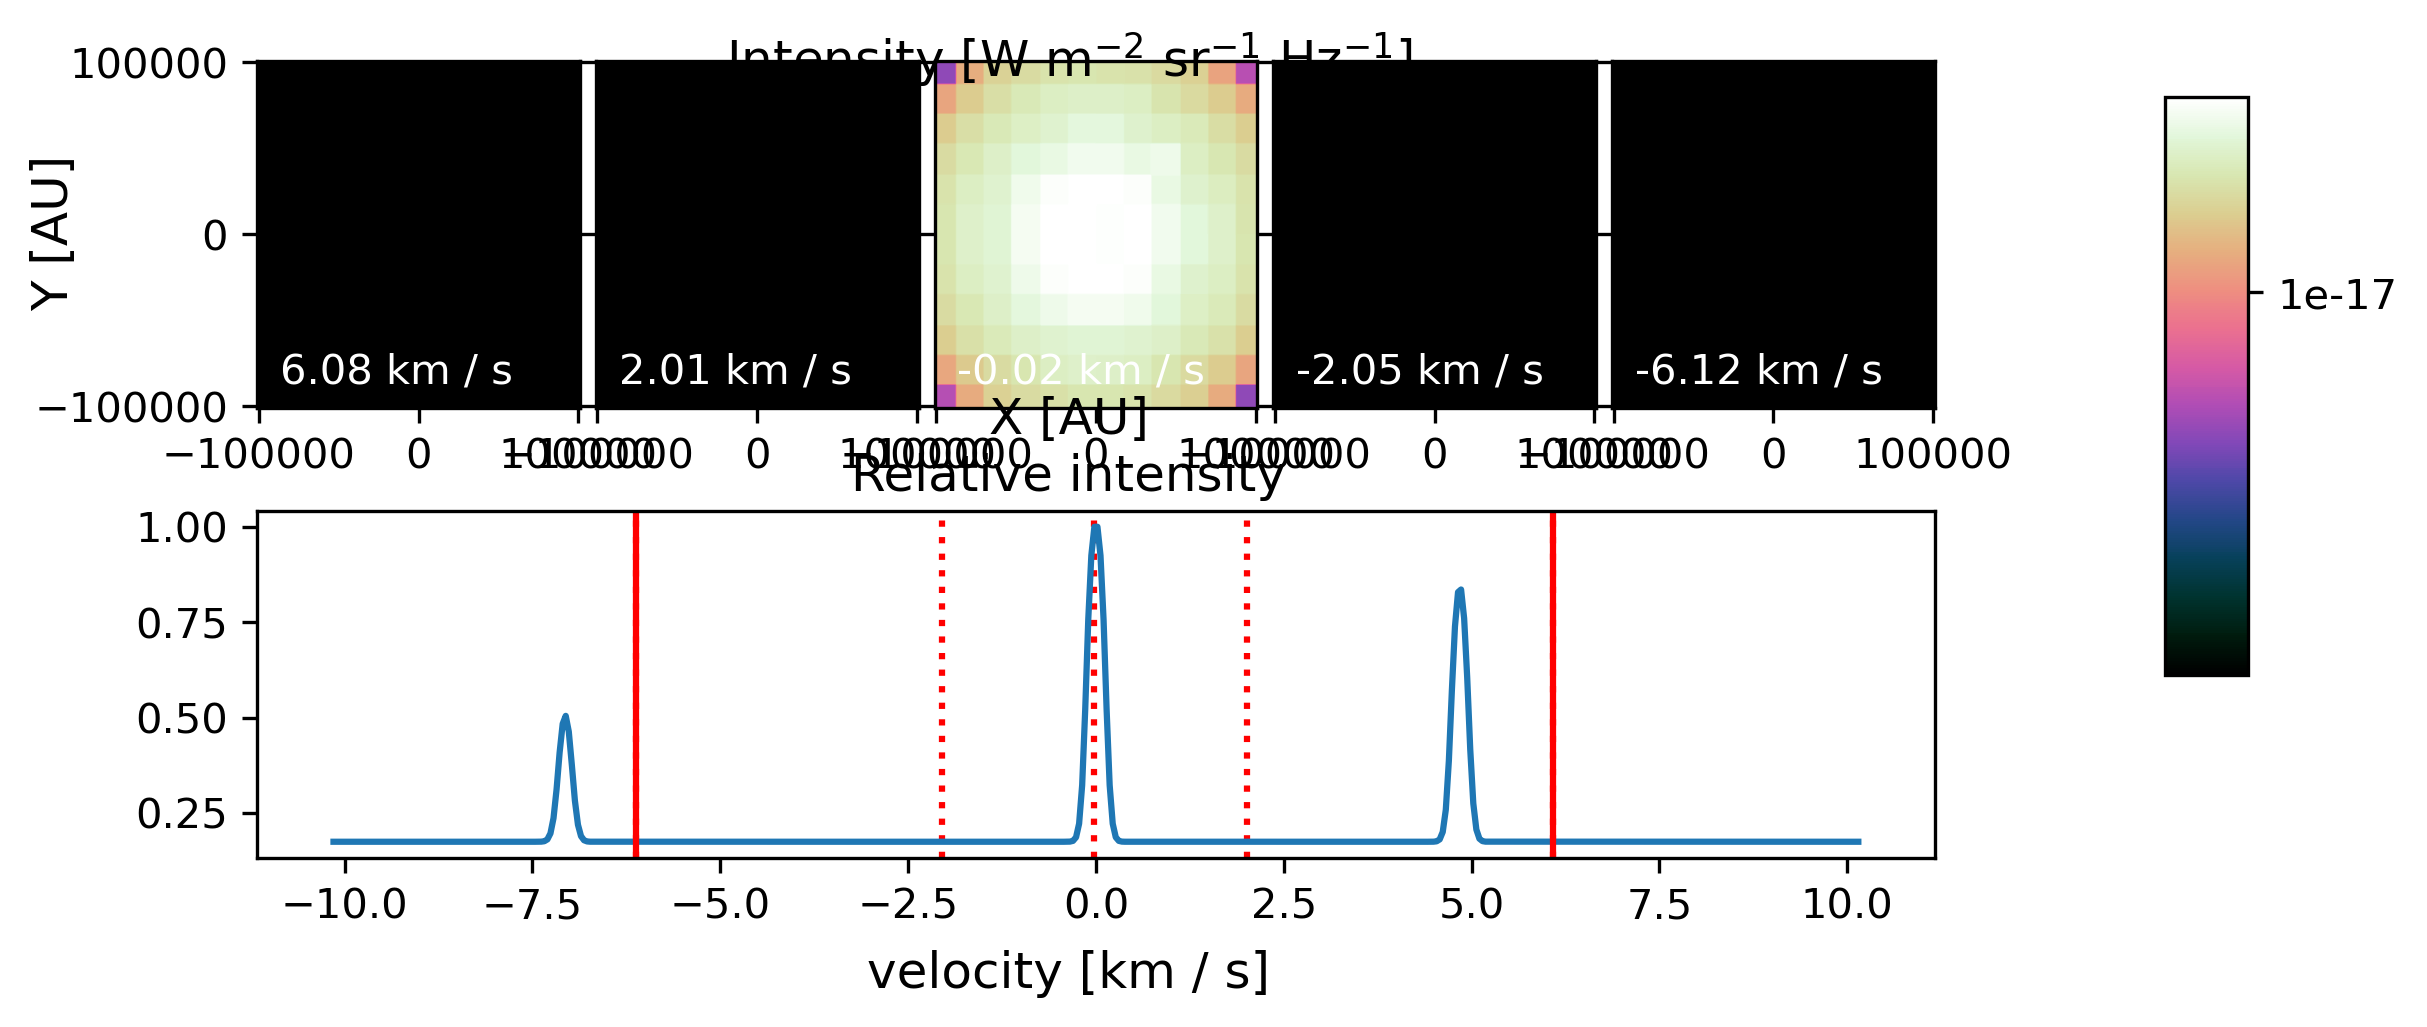

In [58]:
# plot.image_channel(model,[3243,3244],[1,2])
fig=plot.image_channel(model,[100,200,250,300,400],[1,5])
fig

In [59]:
#frequencies and intensities can be extracted from the image object
velos = (np.array(model.images[-1].freqs) - fcen)/fcen*3e8/1000 #convert frequency to velocity in km/s
intensities = np.array(model.images[-1].I)[:,:] #intensities [pixel index, frequency index]
print(intensities.shape) #(nrays, nfreqs)
#see ImX, ImY in model.images[-1] for the pixel coordinates; will need to be multiplied with the (unit) direction vectors: image_direction_x, image_direction_y
pixel_coords_x, pixel_coords_y = np.array(model.images[-1].ImX), np.array(model.images[-1].ImY)
# Is = np.sum(intensities, axis=0) * (np.max(pixel_coords_x) - np.min(pixel_coords_x)) * (np.max(pixel_coords_y) - np.min(pixel_coords_y)) / (len(pixel_coords_x))
Is=(intensities[119,:]+intensities[120,:]+intensities[135,:]+intensities[136,:])/4
print(velos,Is)
len(velos), len(Is)
print(max(Is))

(256, 500)
[-10.15436353 -10.11366468 -10.07296583 -10.03226698  -9.99156812
  -9.95086927  -9.91017042  -9.86947157  -9.82877272  -9.78807386
  -9.74737501  -9.70667616  -9.66597731  -9.62527846  -9.58457961
  -9.54388075  -9.5031819   -9.46248305  -9.4217842   -9.38108535
  -9.34038649  -9.29968764  -9.25898879  -9.21828994  -9.17759109
  -9.13689224  -9.09619338  -9.05549453  -9.01479568  -8.97409683
  -8.93339798  -8.89269912  -8.85200027  -8.81130142  -8.77060257
  -8.72990372  -8.68920486  -8.64850601  -8.60780716  -8.56710831
  -8.52640946  -8.48571061  -8.44501175  -8.4043129   -8.36361405
  -8.3229152   -8.28221635  -8.24151749  -8.20081864  -8.16011979
  -8.11942094  -8.07872209  -8.03802324  -7.99732438  -7.95662553
  -7.91592668  -7.87522783  -7.83452898  -7.79383012  -7.75313127
  -7.71243242  -7.67173357  -7.63103472  -7.59033587  -7.54963701
  -7.50893816  -7.46823931  -7.42754046  -7.38684161  -7.34614275
  -7.3054439   -7.26474505  -7.2240462   -7.18334735  -7.1426485


500


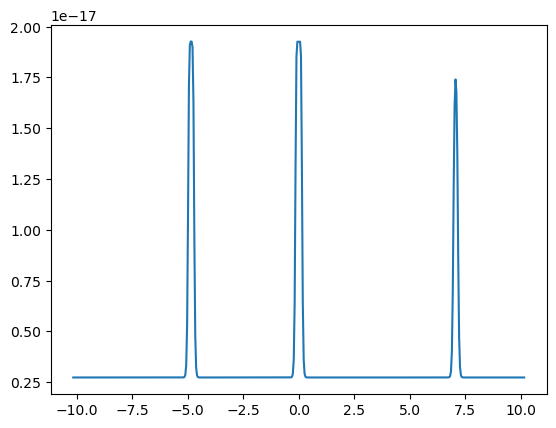

In [60]:
velos1=velos
import matplotlib.pyplot as plt
plt.plot(velos1, Is)

# Save the image to a FITS file conforming to radio 1D format
import astropy.io.fits as fits

hdu = fits.PrimaryHDU(Is)
print(len(velos1))
hdu.header['CRVAL1'] = velos1[0]
hdu.header['CDELT1'] = velos1[1] - velos1[0]
hdu.header['CTYPE1'] = 'VELO-LSR'
hdu.header['CUNIT1'] = 'km/s'
hdu.header['NAXIS1'] = len(velos1)
hdu.header['RESTFREQ'] = fcen  # Rest frequency of the line
hdu.header['CRPIX1'] = 1  # FITS convention for first pixel

fits_file = os.path.join(wdir, 'simulated_hcn_one_zero_unnormalised.fits')
hdu.writeto(fits_file, overwrite=True)


Computing spectral discretisation...
Computing image new...
length: 67
(256, 2295)
[-8.46215049 -8.45477285 -8.44739521 ...  8.44739521  8.45477285
  8.46215049] [3.78867661e-18 3.78867589e-18 3.78867617e-18 ... 3.78861985e-18
 3.78861913e-18 3.78861941e-18]
6.09040262183309e-17


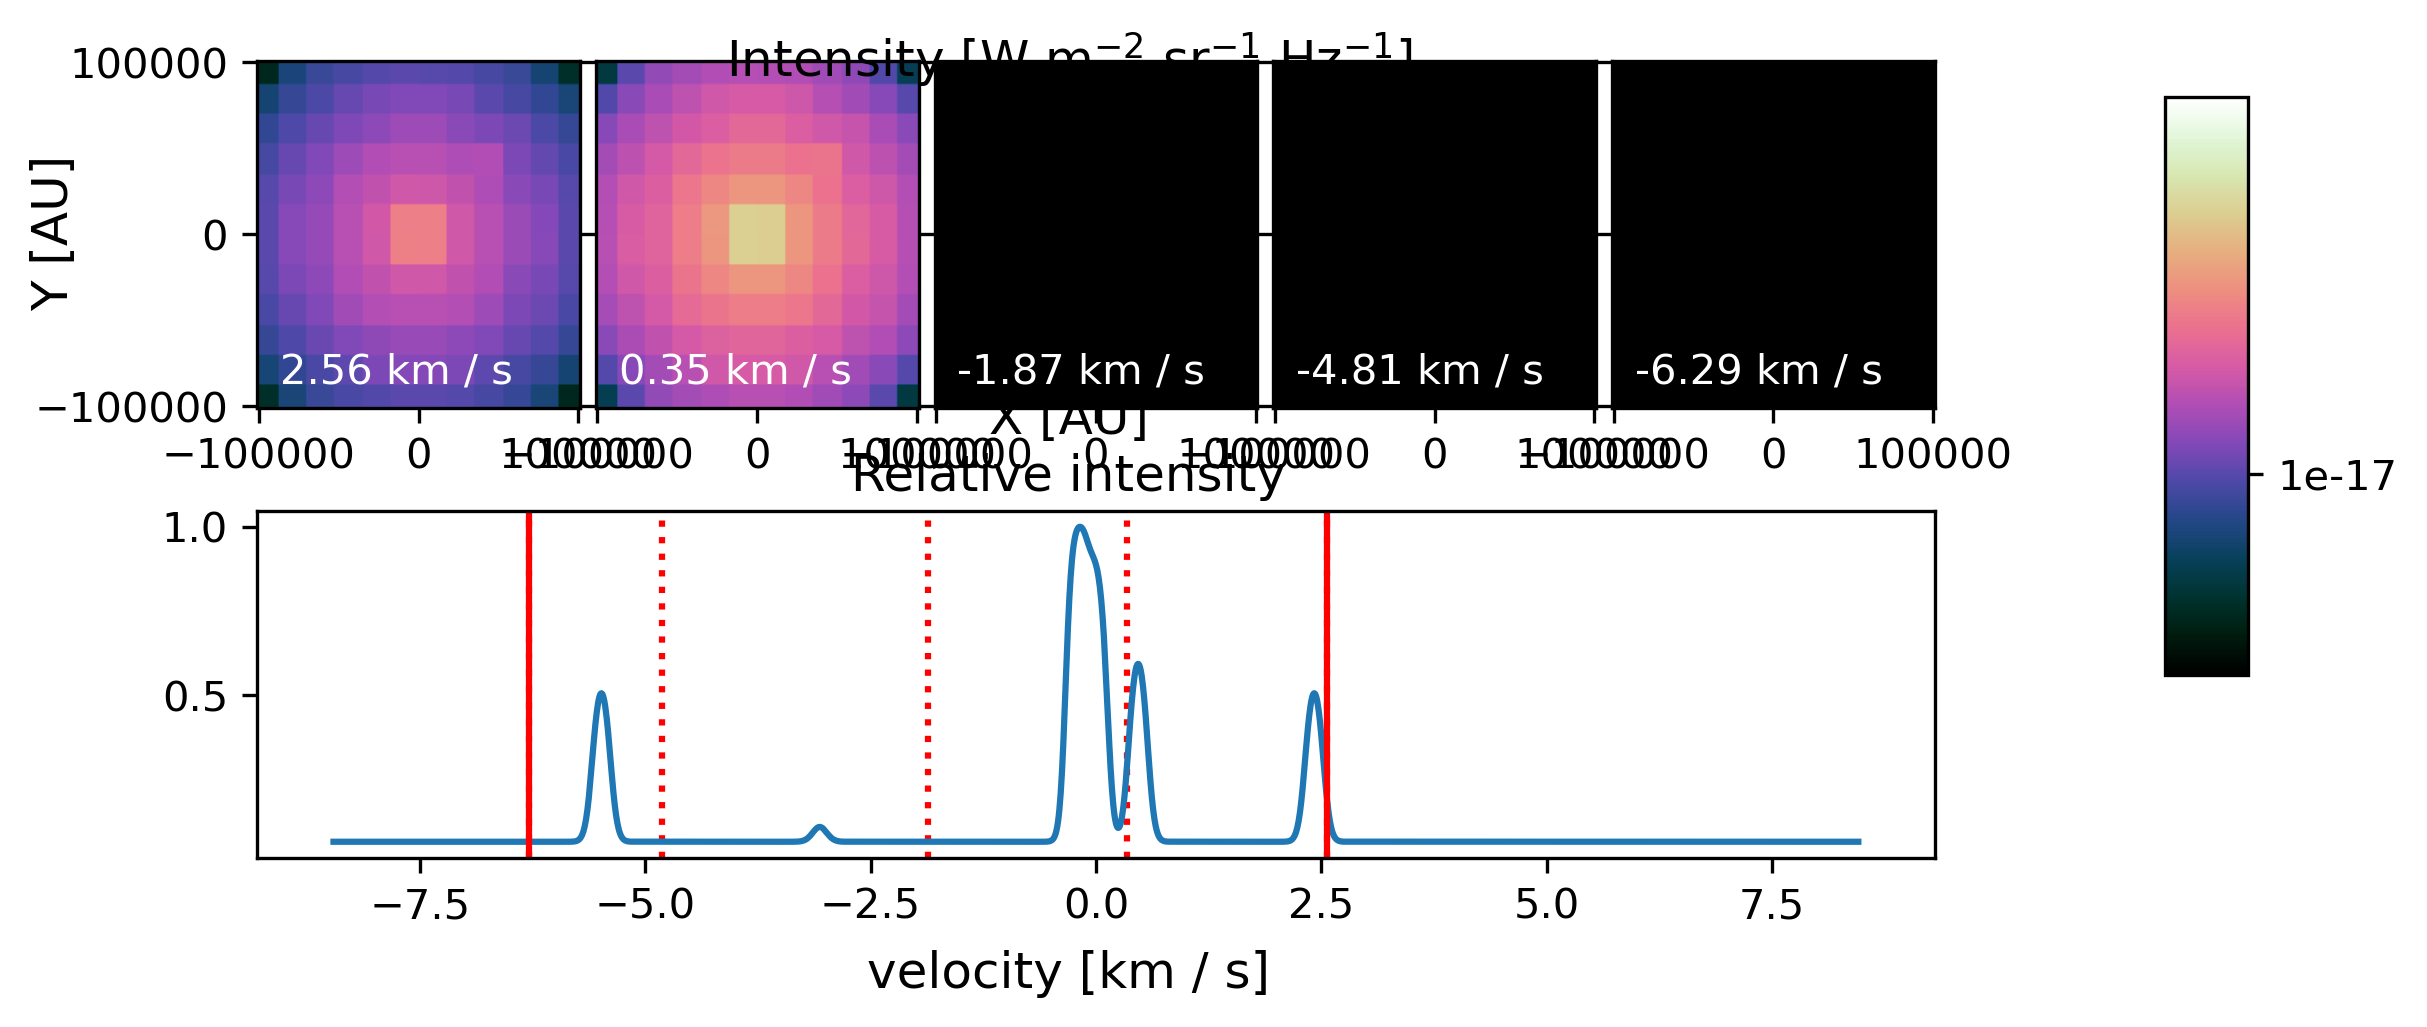

In [61]:


fcen = model.lines.lineProducingSpecies[0].linedata.frequency[5]
fmin=fcen- 5000000.00
fmax=fcen+ 5000000.00
# Ray orthogonal to image plane
ray_nr = 0

model.compute_spectral_discretisation (fmin, fmax)#bins the frequency spectrum [fmin, fmax] into model.parameters.nfreqs bins.
# model.compute_spectral_discretisation (fmin, fmax, 31)#bins using the specified amount of frequency bins (31). Can be any integer >=1

model.compute_image_new               (ray_nr, 16, 16)#using a resolution of 512x512 for the image. 
#Instead of definining a ray index [0, nrays-1], you can also define a ray direction for the imager 

fig=plot.image_channel(model,[800,1100,1400,1800,2000],[1,5])
#frequencies and intensities can be extracted from the image object
velos = (np.array(model.images[-1].freqs) - fcen)/fcen*3e8/1000 #convert frequency to velocity in km/s
intensities = np.array(model.images[-1].I)[:,:] #intensities [pixel index, frequency index]
print(intensities.shape) #(nrays, nfreqs)
#see ImX, ImY in model.images[-1] for the pixel coordinates; will need to be multiplied with the (unit) direction vectors: image_direction_x, image_direction_y
pixel_coords_x, pixel_coords_y = np.array(model.images[-1].ImX), np.array(model.images[-1].ImY)
# Is = np.sum(intensities, axis=0) * (np.max(pixel_coords_x) - np.min(pixel_coords_x)) * (np.max(pixel_coords_y) - np.min(pixel_coords_y)) / (len(pixel_coords_x))
Is=(intensities[119,:]+intensities[120,:]+intensities[135,:]+intensities[136,:])/4
print(velos,Is)
len(velos), len(Is)
print(max(Is))

[-8.46215049 -8.45477285 -8.44739521 ...  8.44739521  8.45477285
  8.46215049]


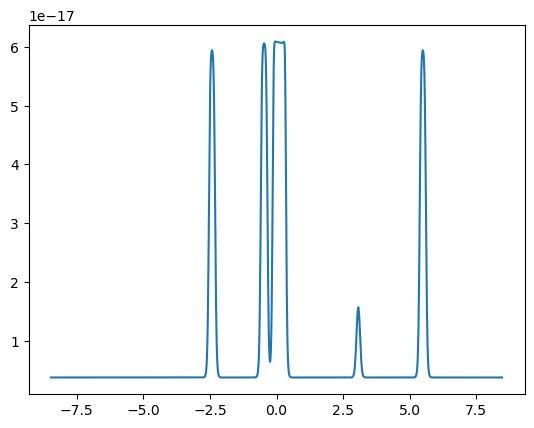

In [62]:
velos2=velos
print(velos2)
#shift velo to have the centre at 0
plt.plot(velos2, Is)

# Save the image to a FITS file conforming to radio 1D format
import astropy.io.fits as fits

hdu = fits.PrimaryHDU(Is)

hdu.header['CRVAL1'] = velos2[0]
hdu.header['CDELT1'] = velos2[1] - velos2[0]
hdu.header['CTYPE1'] = 'VELO-LSR'
hdu.header['CUNIT1'] = 'km/s'
hdu.header['NAXIS1'] = len(velos2)
hdu.header['RESTFREQ'] = fcen  # Rest frequency of the line
hdu.header['CRPIX1'] = 1  # FITS convention for first pixel
fits_file = os.path.join(wdir, 'simulated_hcn_two_one_unnormalised.fits')
hdu.writeto(fits_file, overwrite=True)

Computing spectral discretisation...
Computing image new...
length: 67
(256, 2295)
[-5.6415036  -5.63658512 -5.63166663 ...  5.63166663  5.63658512
  5.6415036 ] [2.59087138e-18 2.59087150e-18 2.59087163e-18 ... 2.59070337e-18
 2.59070350e-18 2.59070363e-18]
1.0685870041802404e-16


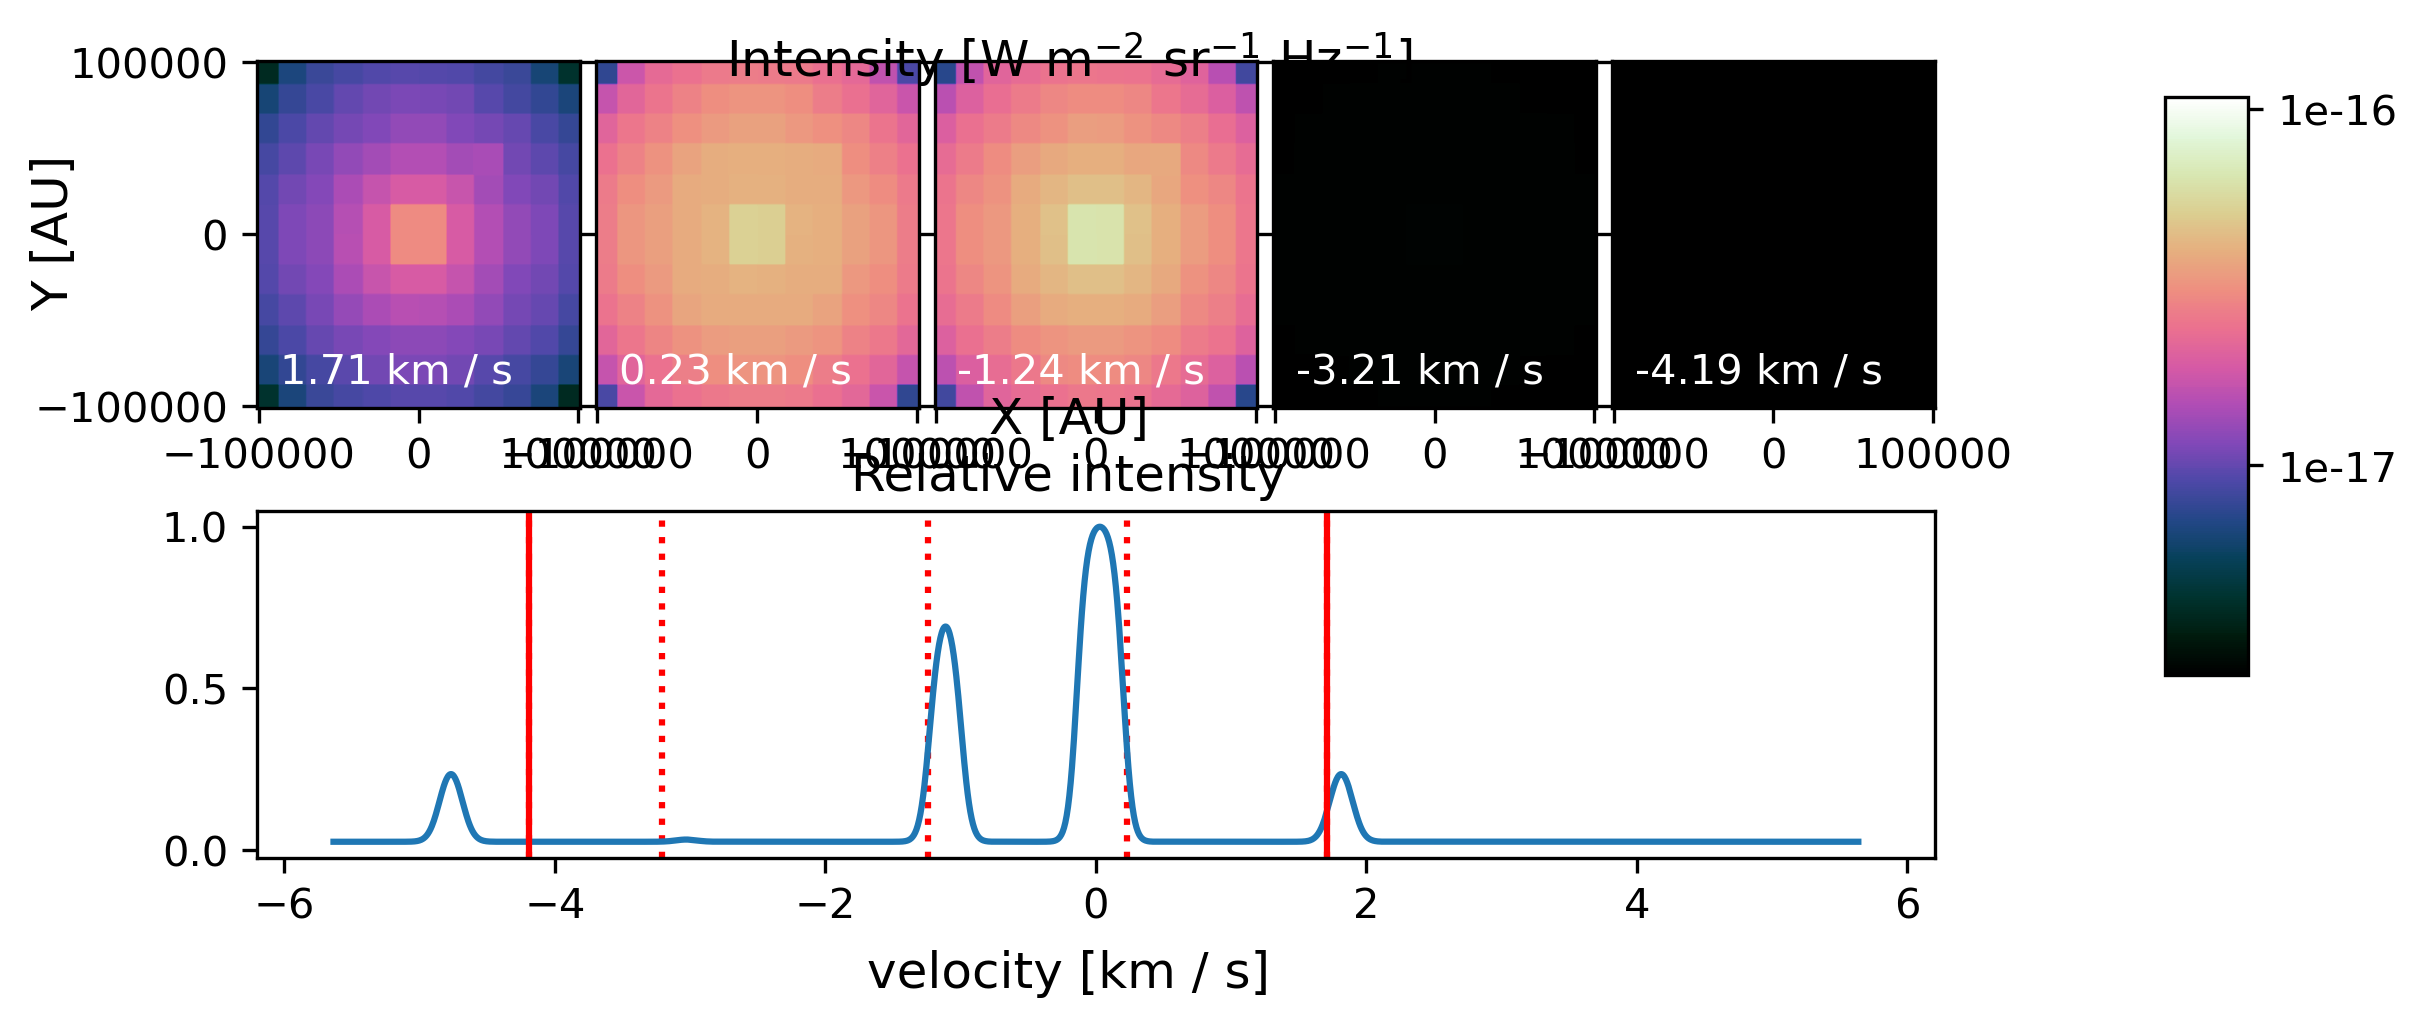

In [63]:
fcen = model.lines.lineProducingSpecies[0].linedata.frequency[12]
fmin=fcen- 5000000.00
fmax=fcen+ 5000000.00
# Ray orthogonal to image plane
ray_nr = 0

model.compute_spectral_discretisation (fmin, fmax)#bins the frequency spectrum [fmin, fmax] into model.parameters.nfreqs bins.
# model.compute_spectral_discretisation (fmin, fmax, 31)#bins using the specified amount of frequency bins (31). Can be any integer >=1

model.compute_image_new               (ray_nr, 16, 16)#using a resolution of 512x512 for the image. 
#Instead of definining a ray index [0, nrays-1], you can also define a ray direction for the imager 

fig=plot.image_channel(model,[800,1100,1400,1800,2000],[1,5])
#frequencies and intensities can be extracted from the image object
velos = (np.array(model.images[-1].freqs) - fcen)/fcen*3e8/1000 #convert frequency to velocity in km/s
intensities = np.array(model.images[-1].I)[:,:] #intensities [pixel index, frequency index]
print(intensities.shape) #(nrays, nfreqs)
#see ImX, ImY in model.images[-1] for the pixel coordinates; will need to be multiplied with the (unit) direction vectors: image_direction_x, image_direction_y
pixel_coords_x, pixel_coords_y = np.array(model.images[-1].ImX), np.array(model.images[-1].ImY)
# Is = np.sum(intensities, axis=0) * (np.max(pixel_coords_x) - np.min(pixel_coords_x)) * (np.max(pixel_coords_y) - np.min(pixel_coords_y)) / (len(pixel_coords_x))
Is=(intensities[119,:]+intensities[120,:]+intensities[135,:]+intensities[136,:])/4
print(velos,Is)
len(velos), len(Is)
print(max(Is))

[-8.46215049 -8.45477285 -8.44739521 ...  8.44739521  8.45477285
  8.46215049]


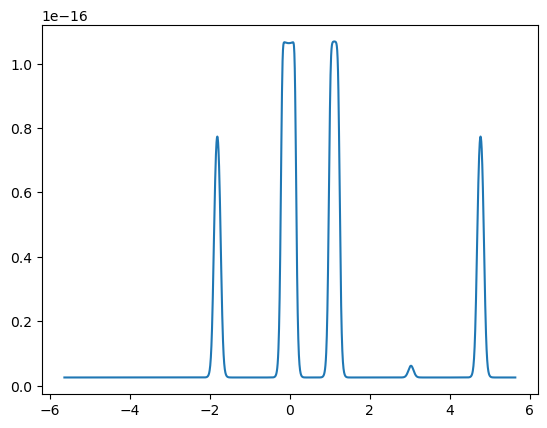

In [64]:
velos3=velos
print(velos2)
#shift velo to have the centre at 0
plt.plot(velos3, Is)

# Save the image to a FITS file conforming to radio 1D format
import astropy.io.fits as fits

hdu = fits.PrimaryHDU(Is)

hdu.header['CRVAL1'] = velos3[0]
hdu.header['CDELT1'] = velos3[1] - velos3[0]
hdu.header['CTYPE1'] = 'VELO-LSR'
hdu.header['CUNIT1'] = 'km/s'
hdu.header['NAXIS1'] = len(velos2)
hdu.header['RESTFREQ'] = fcen  # Rest frequency of the line
hdu.header['CRPIX1'] = 1  # FITS convention for first pixel
fits_file = os.path.join(wdir, 'simulated_hcn_three_two_unnormalised.fits')
hdu.writeto(fits_file, overwrite=True)

In [65]:

from astropy import units as u
import astropy.io.fits as fits
import numpy as np

h  = 6.62607015e-34          # Planck  [J s]
k_B  = 1.380649e-23            # Boltzmann [J K⁻¹]
c  = 2.99792458e8            # speed of light [m s⁻¹]

filenames = {'oneone':'/home/yasho379/ammonia_hfs/Magritte/testing/simulated_nh3_spectrum_oneone_unnormalised.fits',
    'twotwo':'/home/yasho379/ammonia_hfs/Magritte/testing/simulated_nh3_spectrum_twotwo_unnormalised.fits'}

# Load the spectra from the FITS files
spec1 = fits.getdata(filenames['onezero'])
spec2 = fits.getdata(filenames['twoone'])
spec3 = fits.getdata(filenames['threetwo'])


# Get velocity axes from FITS headers
with fits.open(filenames['onezero']) as hdul:
    hdr1 = hdul[0].header
    velos1 = hdr1['CRVAL1'] + np.arange(hdr1['NAXIS1']) * hdr1['CDELT1']

with fits.open(filenames['twoone']) as hdul:
    hdr2 = hdul[0].header
    velos2 = hdr2['CRVAL1'] + np.arange(hdr2['NAXIS1']) * hdr2['CDELT1']

with fits.open(filenames['threetwo']) as hdul:
    hdr3 = hdul[0].header
    velos3 = hdr3['CRVAL1'] + np.arange(hdr3['NAXIS1']) * hdr3['CDELT1']


# Get rest frequencies from headers
freq1 = hdr1['RESTFREQ'] 
freq2 = hdr2['RESTFREQ']
freq3 = hdr3['RESTFREQ']

# Convert intensity (assumed in W/(m^2 Hz sr)) to main beam temperature (K)
def intensity_to_Tmb(v,I, freq):
    Tmb = (c**2 * I) / (2 * k_B * (freq*(1+v/c))**2)
    return Tmb

Tmb1 = intensity_to_Tmb(1000*velos1,spec1, freq1)
Tmb2 = intensity_to_Tmb(1000*velos2,spec2, freq2)
Tmb3 = intensity_to_Tmb(1000*velos3,spec3, freq3)

# now plot the results
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(velos1, Tmb1, label='HCN (1,0)', color='blue')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Tmb (K)')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(velos2, Tmb2, label='HCN (2,1)', color='red')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Tmb (K)')
plt.legend()
plt.plot(velos3, Tmb3, label='HCN (3,2)', color='green')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Tmb (K)')
plt.legend()
plt.tight_layout()
plt.show()



KeyError: 'onezero'

In [ ]:
magritte.version

NameError: name 'magritte' is not defined